In [176]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import glob
import csv
import matplotlib.pyplot as plt

In [177]:
def display_dataframe(in_df):
    in_df = in_df.drop(headers[0], axis=1)
    display(in_df.describe().loc[['count', 'mean', 'std', 'min', 'max']])
    
def plot_data(in_df, plot_title):
    fig, ax = plt.subplots(figsize = (10, 5))
    toPlot = in_df
    
    plot = ax.scatter(toPlot[headers[1]], toPlot[headers[2]])
    ax.set_xlabel('Message Count')
    ax.set_ylabel('Propagation Time (s)')
    plot.ylabel = 'Propagation Time (s)'
    ax.set_title(f'{plot_title}: Propagation Time for {df['#CCs'][0] * 10} CCs')
    ax.grid()

def plot_means(in_data, plot_title):
    fig, ax = plt.subplots(figsize = (10, 5))
    means = pd.DataFrame()
    for df in in_data:
        means = pd.concat([means, df.describe().loc[['mean']] [ [headers[0],headers[2]] ] ])

    toPlot = means
    print(toPlot)
    plot = ax.scatter(toPlot[headers[0]], toPlot[headers[2]])
    ax.set_xlabel('#CCs')
    ax.set_ylabel('Mean Propagation Time (s)')
    plot.ylabel = 'Mean Propagation Time (s)'
    ax.set_title(f'{plot_title}: Mean Propagation Times')
    ax.set_xticks(means[headers[0]])
    ax.grid()

'''
CONSTANTS FOR ANALYSIS
'''
DATA_PATH = 'time_data_*'

file_paths = glob.glob(DATA_PATH)
headers = ['#CCs', 'message_count', 'propagation_time']

'''
Change these to change behavior
'''
ZSCORE_LIMIT = 2.5

In [191]:
data = []
pruned_data = []

for path in file_paths:
    newDf = pd.read_csv(path, header = None, names = headers)
    newDf = newDf.dropna()
    if not newDf.empty:
        data.append(newDf)

for df in data:
    new_df = df[['#CCs', 'propagation_time']]
    pruned_df = df.copy()
    # now we drop statistical outliers. Lets also display how many those are.
    # we'll keep that info and out the raw and the pruned datasets
    
    pruned_df['zscore'] = zscore(pruned_df['propagation_time'])
    pruned_df = pruned_df[abs(pruned_df['zscore']) < ZSCORE_LIMIT].drop('zscore', axis=1)
    pruned_data.append(pruned_df)
        

In [192]:
'''
PRINT DATA INFORMATION
'''
for df, p_df in zip(data, pruned_data):
    print(f'{df['#CCs'][0] * 10} CC servers information')
    print('RAW DATA')
    display_dataframe(df)
    print('PRUNED DATA')
    display_dataframe(p_df)


10 CC servers information
RAW DATA


,message_count,propagation_time
count,100.000000,100.000000
mean,50.500000,2.141809
std,29.011492,1.488936
min,1.000000,1.339786
max,100.000000,12.226660


PRUNED DATA


,message_count,propagation_time
count,97.000000,97.000000
mean,49.597938,1.902583
std,28.815021,0.502470
min,1.000000,1.339786
max,99.000000,5.739756


20 CC servers information
RAW DATA


...

,message_count,propagation_time
count,98.000000,98.000000
mean,51.010204,9.195560
std,28.887444,6.224782
min,1.000000,3.833630
max,100.000000,25.773342


40 CC servers information
RAW DATA


,message_count,propagation_time
count,100.000000,100.000000
mean,50.500000,12.348802
std,29.011492,8.202251
min,1.000000,4.669157
max,100.000000,67.981271


PRUNED DATA


,message_count,propagation_time
count,99.000000,99.000000
mean,50.989899,11.786858
std,28.740391,6.005253
min,1.000000,4.669157
max,100.000000,29.981789


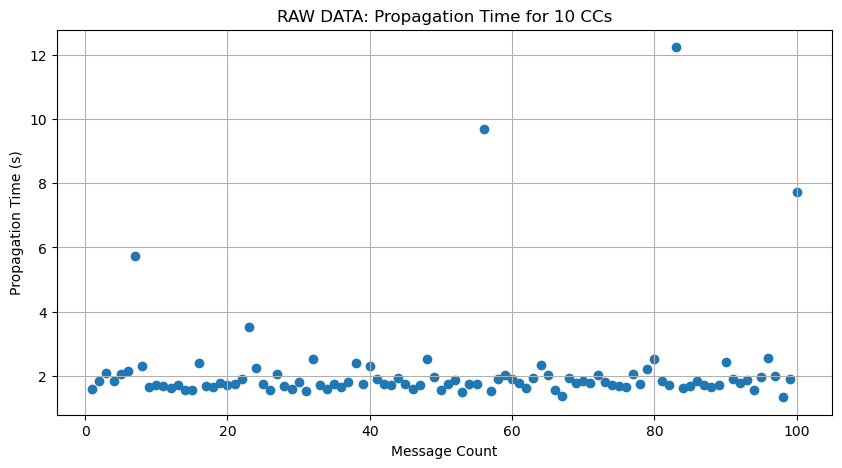

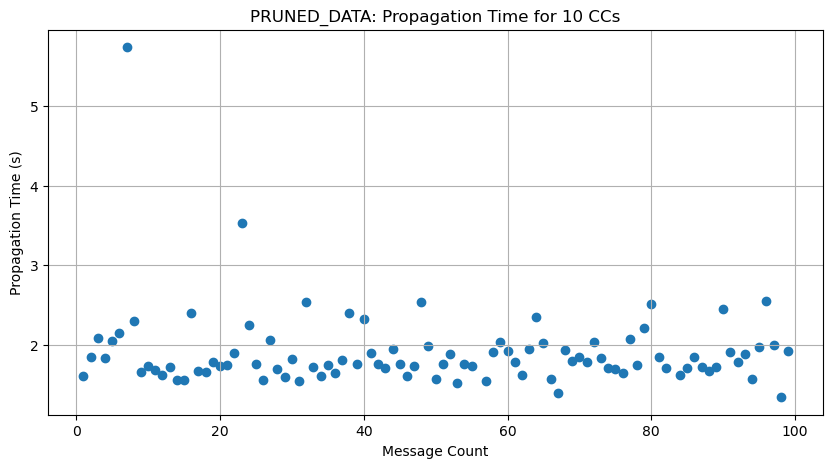

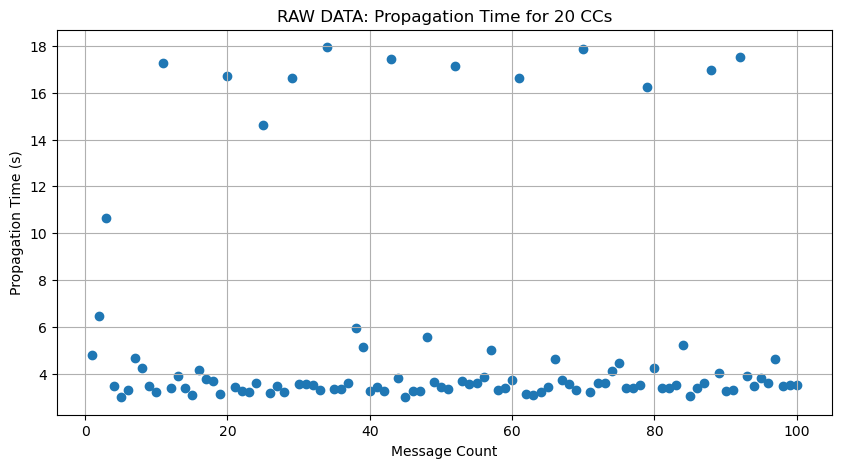

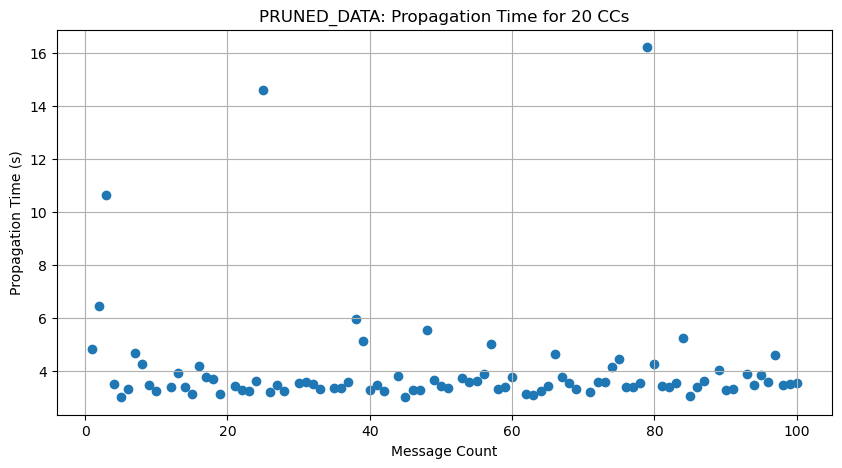

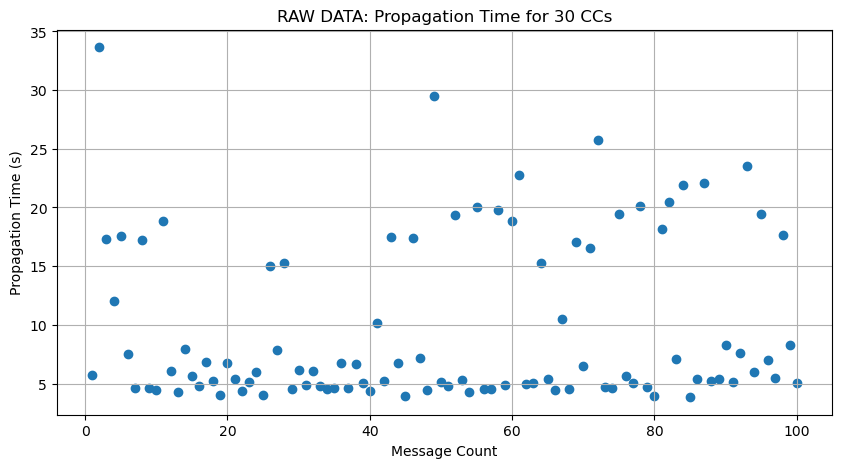

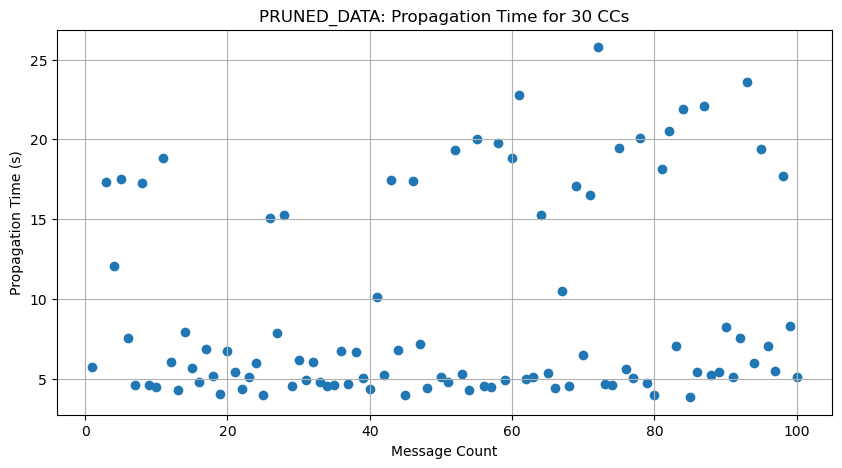

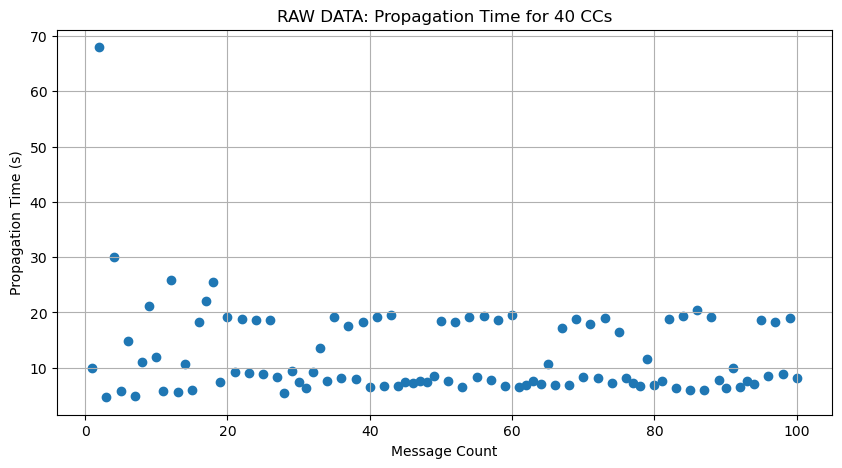

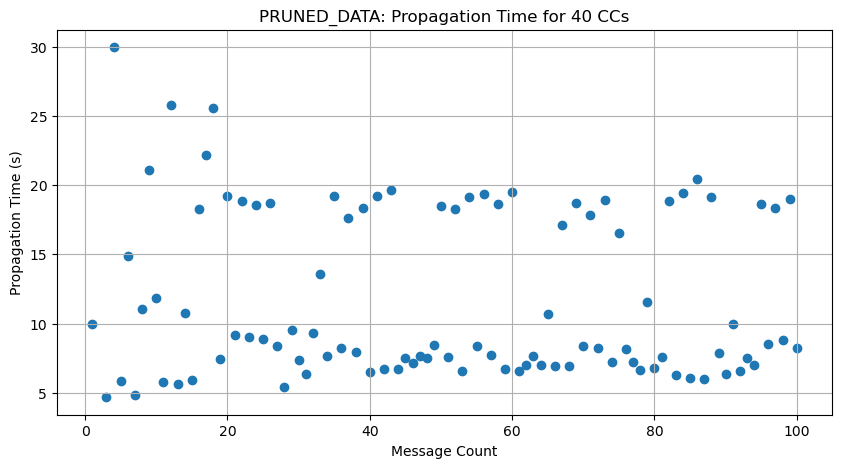

In [193]:
'''
GRAPH DATA
'''
for df, p_df in zip(data, pruned_data):
    plot_data(df, 'RAW DATA')
    plot_data(p_df, 'PRUNED_DATA')

      #CCs  propagation_time
mean   1.0          2.141809
mean   2.0          5.345668
mean   3.0          9.643235
mean   4.0         12.348802


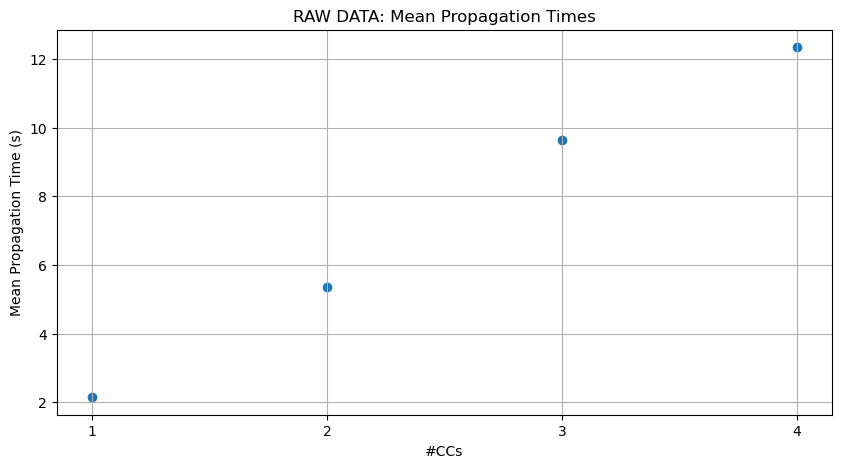

In [194]:
plot_means(data, 'RAW DATA')

      #CCs  propagation_time
mean   1.0          1.902583
mean   2.0          4.026853
mean   3.0          9.195560
mean   4.0         11.786858


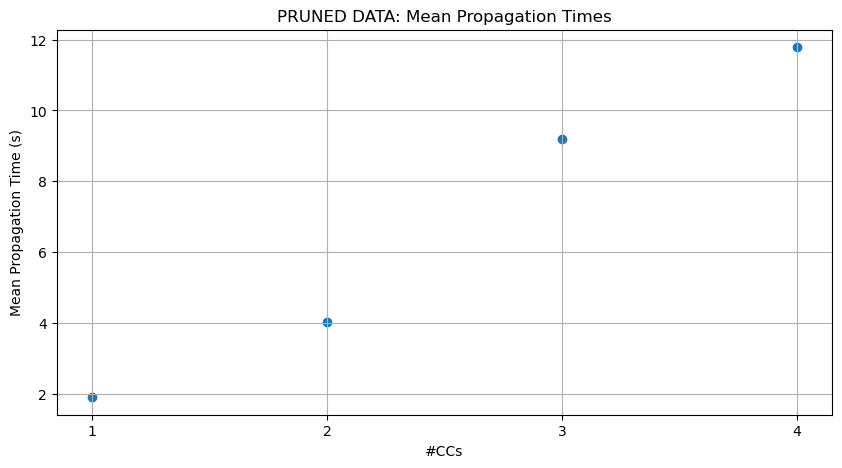

In [195]:
plot_means(pruned_data, 'PRUNED DATA')